In [117]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import pandas as pd

In [144]:
def decode_decimal_year_time(ds, time_name='time', inplace=False):
    """
    Convert decimal year time coordinate to datetime64.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing decimal year time values.
    time_name : str
        Name of the time variable.
    inplace : bool
        If True, modifies dataset in place.

    Returns
    -------
    xarray.Dataset
        Dataset with decoded datetime time coordinate.
    """
    t = ds[time_name].values
    year = np.floor(t).astype(int)
    frac = t - year
    days_in_year = np.where((year % 4 == 0) & ((year % 100 != 0) | (year % 400 == 0)),366, 365)

    time = (pd.to_datetime([f"{y}-01-01" for y in year]) + pd.to_timedelta(frac * days_in_year, unit="D")
    )

    if inplace:
        ds[time_name].values = time
        return ds
    else:
        ds = ds.copy()
        ds[time_name] = (time_name, time)
        return ds

In [147]:

# Load ROMS model output
# roms_file = 'roms_output.nc'  # Replace with your ROMS output file
# ds_roms = xr.open_dataset(roms_file)

# Define observation data 
obs_file = '../data/raw/MIPkit-A/Oce3d_MIPkitA_1994.nc'  
ds_obs_oce3d = xr.open_dataset(obs_file)

# Define observation data 
obs_file = '../data/raw/MIPkit-A/OceSec1_MIPkitA_2009.nc'  
ds_obs_ocesec1_2009 = xr.open_dataset(obs_file)
ds_obs_ocesec1_2009 = ds_obs_ocesec1_2009.set_coords(['lat', 'time'])

obs_file = '../data/raw/MIPkit-A/OceMoor1_MIPkitA_PIGN.nc'  
ds_obs_ocemoor1_pign = xr.open_dataset(obs_file, decode_times=False)
ds_obs_ocemoor1_pign = decode_decimal_year_time(ds_obs_ocemoor1_pign)

obs_file = '../data/raw/MIPkit-A/OceMoor2_MIPkitA_PIGS.nc'  
ds_obs_ocemoor2_pigs = xr.open_dataset(obs_file, decode_times=False)
ds_obs_ocemoor2_pigs = decode_decimal_year_time(ds_obs_ocemoor2_pigs)

obs_file = '../data/raw/MIPkit-A/OceMoor3_MIPkitA_PITE.nc'  
ds_obs_ocemoor3_pite = xr.open_dataset(obs_file, decode_times=False)
ds_obs_ocemoor3_pite = decode_decimal_year_time(ds_obs_ocemoor3_pite)

obs_file = '../data/raw/MIPkit-A/OceMoor4_MIPkitA_PITW.nc'  
ds_obs_ocemoor4_pitw = xr.open_dataset(obs_file, decode_times=False)
ds_obs_ocemoor4_pitw = decode_decimal_year_time(ds_obs_ocemoor4_pitw)

# Amundsen Sea region coordinates
lon_min, lon_max = -105, -95
lat_min, lat_max = -75, -70


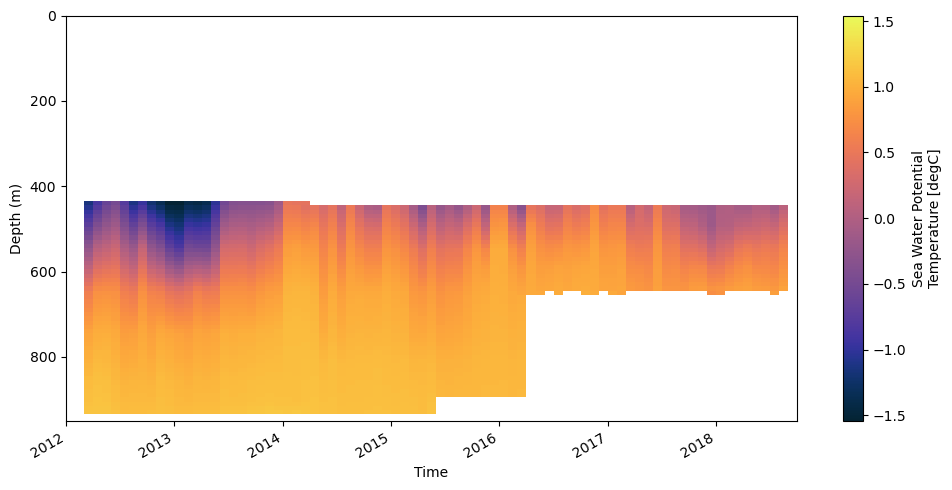

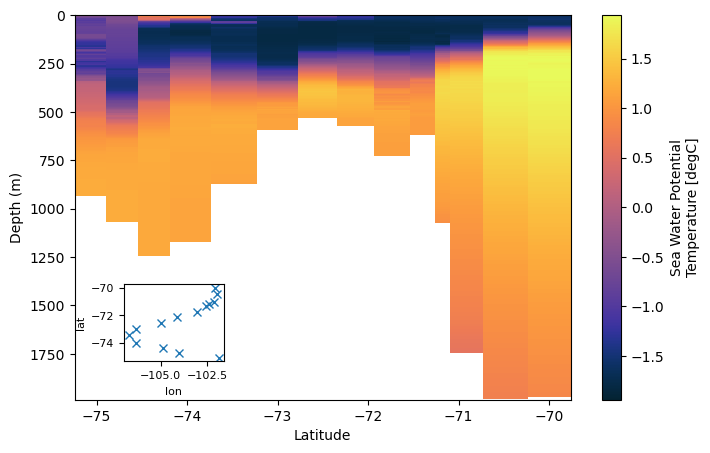

In [86]:
fig = plt.figure(figsize=(8, 5))
gs = gridspec.GridSpec(1, 1)

# --- Main section plot ---
ax = fig.add_subplot(gs[0])

sec = ds_obs_ocesec1_2009.thetao.sortby('lat').plot(ax=ax,x='lat',y='lev', cmap=cmocean.cm.thermal,
add_colorbar=True
)

ax.invert_yaxis()  # flip depth axis
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Latitude')

# --- Inset: station locations ---
ax_inset = inset_axes(ax, width="20%", height="20%", loc='lower left',bbox_to_anchor=(0.1, .1, 1, 1),bbox_transform=ax.transAxes,borderpad=0)

ax_inset.plot(ds_obs_ocesec1_2009.lon, ds_obs_ocesec1_2009.lat, 'x')
ax_inset.set_xlabel('lon', fontsize=8)
ax_inset.set_ylabel('lat', fontsize=8)
ax_inset.tick_params(labelsize=8)


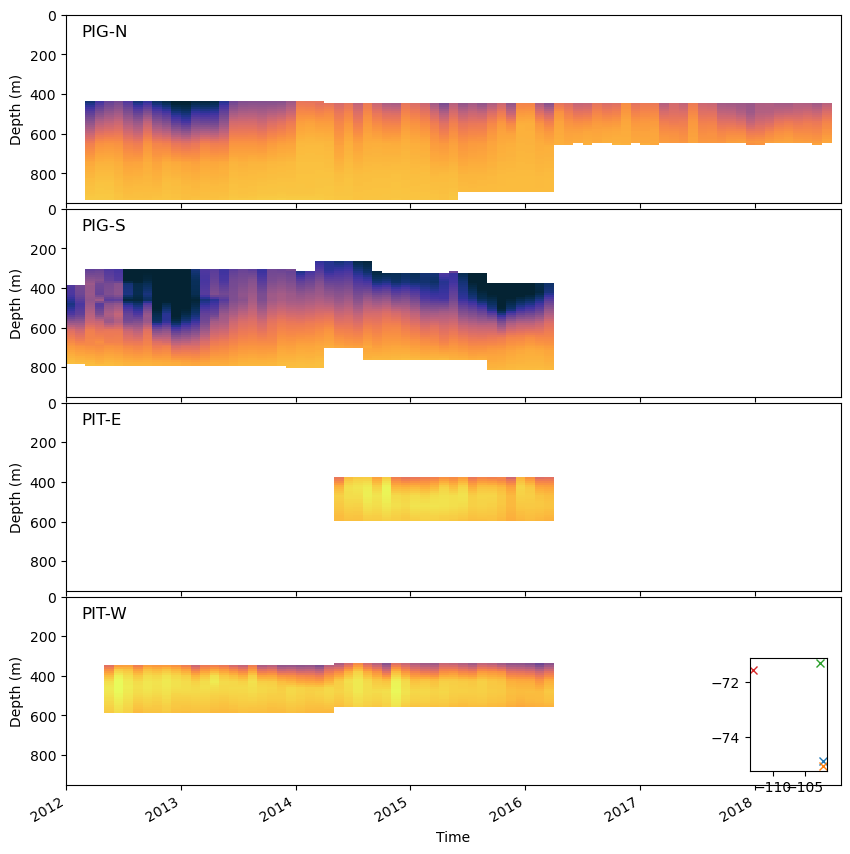

In [168]:

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(4, 1, hspace=0.03)

# ROW 1: main plot
ax = fig.add_subplot(gs[0])
im = ds_obs_ocemoor1_pign.thetao.plot(ax=ax,x='time',y='lev',cmap=cmocean.cm.thermal,add_colorbar=False,vmin=-1.5,vmax=1.5)
ax.text(0.02, 0.95, 'PIG-N', transform=ax.transAxes, fontsize=12, verticalalignment='top')

# flip y-axis (depth increasing downward)
ax.invert_yaxis()

# make axes tight to data
ax.set_xlim(np.datetime64('2012-01-01'), np.datetime64('2018-10-01'))
ax.set_ylim(950,0)
ax.set_xlabel('')
ax.set_ylabel('Depth (m)')
ax.set_xticklabels([])  # hide x-axis labels for top plot


# ROW 2: main plot
ax = fig.add_subplot(gs[1])
im = ds_obs_ocemoor2_pigs.thetao.plot(ax=ax,x='time',y='lev',cmap=cmocean.cm.thermal,add_colorbar=False,vmin=-1.5,vmax=1.5)
ax.text(0.02, 0.95, 'PIG-S', transform=ax.transAxes, fontsize=12, verticalalignment='top')

# flip y-axis (depth increasing downward)
ax.invert_yaxis()
# make axes tight to data
ax.set_xlim(np.datetime64('2012-01-01'), np.datetime64('2018-10-01'))
ax.set_ylim(950,0)
ax.set_xlabel('')
ax.set_ylabel('Depth (m)')
ax.set_xticklabels([])  # hide x-axis labels for middle plots


# ROW 3: main plot
ax = fig.add_subplot(gs[2])
im = ds_obs_ocemoor3_pite.thetao.plot(ax=ax,x='time',y='lev',cmap=cmocean.cm.thermal,add_colorbar=False,vmin=-1.5,vmax=1.5)
ax.text(0.02, 0.95, 'PIT-E', transform=ax.transAxes, fontsize=12, verticalalignment='top')
# flip y-axis (depth increasing downward)
ax.invert_yaxis()
# make axes tight to data
ax.set_xlim(np.datetime64('2012-01-01'), np.datetime64('2018-10-01'))
ax.set_ylim(950,0)
ax.set_xlabel('')
ax.set_ylabel('Depth (m)')
ax.set_xticklabels([])  # hide x-axis labels for middle plots


# ROW 4: main plot
ax = fig.add_subplot(gs[3])
im = ds_obs_ocemoor4_pitw.thetao.plot(ax=ax,x='time',y='lev',cmap=cmocean.cm.thermal,add_colorbar=False,vmin=-1.5,vmax=1.5)
ax.text(0.02, 0.95, 'PIT-W', transform=ax.transAxes, fontsize=12, verticalalignment='top')
# flip y-axis (depth increasing downward)
ax.invert_yaxis()
# make axes tight to data
ax.set_xlim(np.datetime64('2012-01-01'), np.datetime64('2018-10-01'))
ax.set_ylim(950,0)
ax.set_xlabel('Time')
ax.set_ylabel('Depth (m)')

ax_inset = inset_axes(ax,width="10%",height="60%",loc='lower right',borderpad=1)
ax_inset.plot(ds_obs_ocemoor1_pign.lon, ds_obs_ocemoor1_pign.lat, 'x', label='PIG-N')
ax_inset.plot(ds_obs_ocemoor2_pigs.lon, ds_obs_ocemoor2_pigs.lat, 'x', label='PIG-S')
ax_inset.plot(ds_obs_ocemoor3_pite.lon, ds_obs_ocemoor3_pite.lat, 'x', label='PIG-E')
ax_inset.plot(ds_obs_ocemoor4_pitw.lon, ds_obs_ocemoor4_pitw.lat, 'x', label='PIG-W')

plt.show()



In [ ]:

# # ============================================================
# # TRANSECT PLOTS
# # ============================================================

# def plot_transect_comparison(ds_model, ds_obs, var_name, lon_transect, depth_dim='depth'):
#     """Create transect comparison plot for a given longitude."""
    
#     fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
#     # Model transect
#     model_subset = ds_model[var_name].sel(longitude=lon_transect, method='nearest')
#     im1 = axes[0].contourf(model_subset[depth_dim], model_subset.latitude, 
#                            model_subset.T, cmap=cmocean.cm.thermal, levels=20)
#     axes[0].set_ylabel('Latitude')
#     axes[0].set_title(f'ROMS Model - {var_name} at {lon_transect}°W')
#     plt.colorbar(im1, ax=axes[0], label=var_name)
    
#     # Observation transect
#     obs_subset = ds_obs[var_name].sel(longitude=lon_transect, method='nearest')
#     im2 = axes[1].contourf(obs_subset[depth_dim], obs_subset.latitude, 
#                            obs_subset.T, cmap=cmocean.cm.thermal, levels=20)
#     axes[1].set_ylabel('Latitude')
#     axes[1].set_xlabel('Depth (m)')
#     axes[1].set_title(f'Observations - {var_name} at {lon_transect}°W')
#     plt.colorbar(im2, ax=axes[1], label=var_name)
    
#     plt.tight_layout()
#     return fig

# # Example transect at -100°W
# var = 'temperature'
# fig_transect = plot_transect_comparison(ds_roms, ds_obs, var, -100)
# fig_transect.savefig('transect_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ============================================================
# # MOORING PLOTS
# # ============================================================

# def plot_moorings(ds_model, ds_obs, mooring_lons, mooring_lats, var_name):
#     """Create time series comparison plots for mooring locations."""
    
#     n_moorings = len(mooring_lons)
#     fig, axes = plt.subplots(n_moorings, 1, figsize=(12, 3*n_moorings), sharex=True)
    
#     if n_moorings == 1:
#         axes = [axes]
    
#     for i, (lon, lat) in enumerate(zip(mooring_lons, mooring_lats)):
#         # Model data at mooring location
#         model_subset = ds_model[var_name].sel(
#             longitude=lon, method='nearest'
#         ).sel(latitude=lat, method='nearest')
        
#         # Observation data at mooring location
#         obs_subset = ds_obs[var_name].sel(
#             longitude=lon, method='nearest'
#         ).sel(latitude=lat, method='nearest')
        
#         # Plot comparison
#         axes[i].plot(model_subset.time, model_subset, label='ROMS Model', linewidth=1.5)
#         axes[i].plot(obs_subset.time, obs_subset, label='Observations', 
#                     marker='o', markersize=3, linestyle='--', alpha=0.7)
#         axes[i].set_ylabel(var_name)
#         axes[i].set_title(f'Mooring: {lon}°W, {lat}°S')
#         axes[i].legend(loc='upper right')
#         axes[i].grid(True, alpha=0.3)
    
#     axes[-1].set_xlabel('Time')
#     plt.tight_layout()
#     return fig


In [ ]:

# # Define mooring locations in Amundsen Sea
# mooring_lons = [-102, -100, -98]
# mooring_lats = [-73, -72, -71]

# # Temperature mooring comparison
# fig_temp = plot_moorings(ds_roms, ds_obs, mooring_lons, mooring_lats, 'temperature')
# fig_temp.savefig('mooring_temperature.png', dpi=150, bbox_inches='tight')
# plt.show()

# # Salinity mooring comparison
# fig_salt = plot_moorings(ds_roms, ds_obs, mooring_lons, mooring_lats, 'salinity')
# fig_salt.savefig('mooring_salinity.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ============================================================
# # STATISTICS SUMMARY
# # ============================================================

# def compute_statistics(ds_model, ds_obs, var_name):
#     """Compute comparison statistics between model and observations."""
    
#     model_data = ds_model[var_name].values.flatten()
#     obs_data = ds_obs[var_name].values.flatten()
    
#     # Remove NaN values
#     valid_mask = ~np.isnan(model_data) & ~np.isnan(obs_data)
#     model_valid = model_data[valid_mask]
#     obs_valid = obs_data[valid_mask]
    
#     # Compute metrics
#     bias = np.mean(model_valid - obs_valid)
#     rmse = np.sqrt(np.mean((model_valid - obs_valid)**2))
#     corr = np.corrcoef(model_valid, obs_valid)[0, 1]
    
#     return {'bias': bias, 'rmse': rmse, 'correlation': corr}

# # Compute statistics for key variables
# variables = ['temperature', 'salinity', 'velocity_u', 'velocity_v']
# stats_summary = {}

# for var in variables:
#     if var in ds_roms and var in ds_obs:
#         stats_summary[var] = compute_statistics(ds_roms, ds_obs, var)

# # Print statistics
# print("=" * 50)
# print("Model-Observation Comparison Statistics")
# print("=" * 50)
# for var, stats in stats_summary.items():
#     print(f"\n{var}:")
#     print(f"  Bias: {stats['bias']:.3f}")
#     print(f"  RMSE: {stats['rmse']:.3f}")
#     print(f"  Correlation: {stats['correlation']:.3f}")